In [59]:
import pandas as pd
import seaborn as sns
main_data=pd.read_excel('data.xlsx')
print(len(main_data))


# Print column names
print(main_data.columns)
# Print data types of each column
print(main_data.dtypes)
# Print summary statistics for numerical columns
print(main_data.describe())



40
Index(['participant', 'age', 'gender', 'gender_other', 'vr_experience',
       'valence_v1', 'arousal_v1', 'emotion_v1', 'features_v1', 'immersion_v1',
       'v1', 'valence_v2', 'arousal_v2', 'emotion_v2', 'features_v2',
       'immersion_v2', 'v2', 'valence_v3', 'arousal_v3', 'emotion_v3',
       'features_v3', 'immersion_v3', 'v3', 'valence_v4', 'arousal_v4',
       'emotion_v4', 'features_v4', 'immersion_v4', 'v4', 'valence_v5',
       'arousal_v5', 'emotion_v5', 'features_v5', 'immersion_v5', 'v5',
       'phq_1', 'phq_2', 'phq_3', 'phq_4', 'phq_5', 'phq_6', 'phq_7', 'phq_8',
       'phq_9', 'gad_1', 'gad_2', 'gad_3', 'gad_4', 'gad_5', 'gad_6', 'gad_7',
       'seek_therapy_check', 'score_vrise', 'score_gad', 'score_phq',
       'score_stai_t', 'positive_affect_start', 'negative_affect_start',
       'positive_affect_end', 'negative_affect_end', 'feedback', 'TIME_start',
       'TIME_end', 'TIME_total'],
      dtype='object')
participant                    object
age           

In [60]:
# Print missing or NaN percentage for each column where it is not zero
missing_percentage = main_data.isnull().mean() * 100
print(missing_percentage[missing_percentage != 0])


# Drop gender_other since it is completely empty
main_data = main_data.drop(columns=['gender_other'])



gender_other    100.0
emotion_v1        5.0
features_v1       5.0
emotion_v2        5.0
features_v2       5.0
emotion_v3        2.5
features_v3       7.5
emotion_v4        5.0
features_v4       7.5
emotion_v5        5.0
features_v5       5.0
feedback         45.0
dtype: float64


# Missing data observations
- gender_other column is entirely empty. Therefore, should drop.
- feedback column is almost half empty(45% or 18 participants). It can be used for manual analysis but drawing inferences might not be reliable.
- emotion and features for all videos have some missing data(1- 3 people) [Manual analysis reveals that 2 people have not filled out the fields] -> These people will need to be excluded when using the attributes.


# Manual Data Observations
- One guy has consistently filled out 'Niket Mittal' as emotion. So will need to exclude him when doing analysis.
- Two guys have left out most of the emotion and features part 
- Feedback column is not very useful for the hypothesis.
- Since ML methods are forbidden, we will not be analysing string fields for now. Will see it later ig.






count    40.000000
mean     22.775000
std       1.804375
min      19.000000
25%      21.000000
50%      23.000000
75%      24.000000
max      27.000000
Name: age, dtype: float64
gender
1    36
2     4
Name: count, dtype: int64


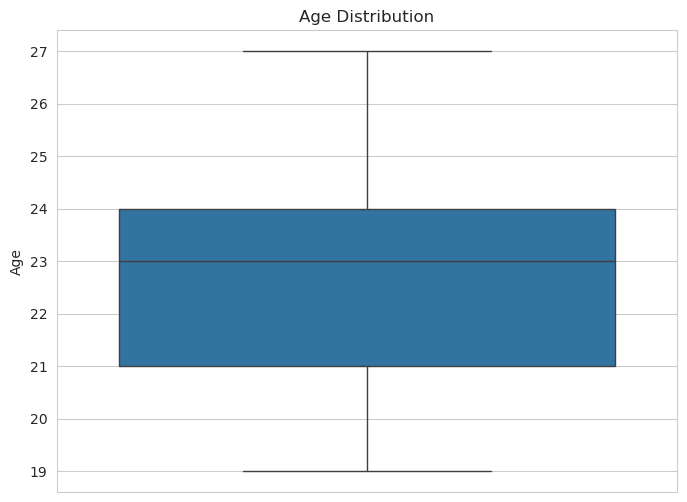

/tmp/ipykernel_1847/3871673770.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2')


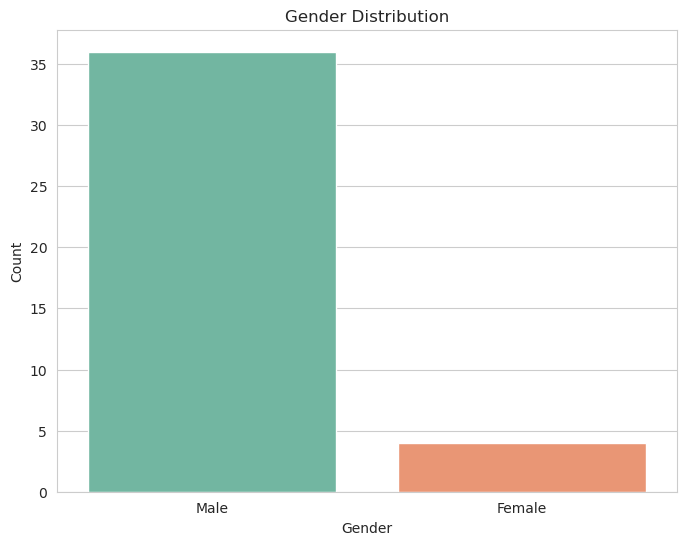

/tmp/ipykernel_1847/3871673770.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vr_exp_counts.index, y=vr_exp_counts.values, palette='viridis')


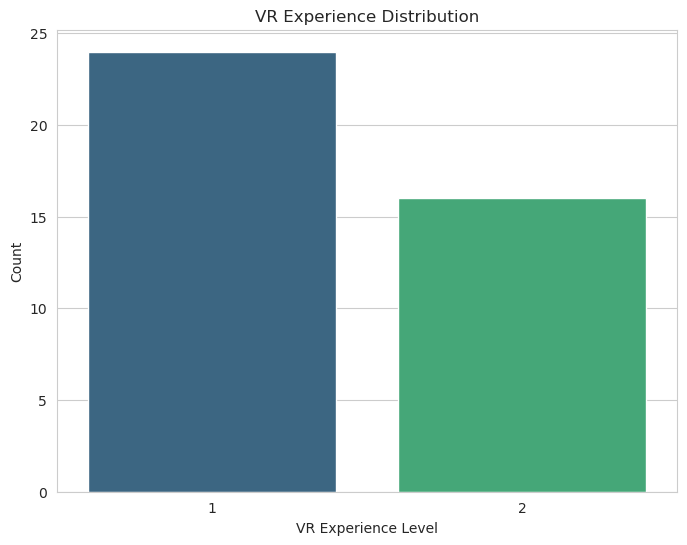

In [61]:
# Demographic Analysis (using gender and age columns)

# Print descriptive statistics for age and gender
print(main_data['age'].describe())
print(main_data['gender'].value_counts())


# Plot age boxplot  
import matplotlib.pyplot as plt

# Set seaborn style
sns.set_style("whitegrid")

# Age boxplot using seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(y=main_data['age'])
plt.title('Age Distribution')
plt.ylabel('Age')
plt.show()

# Bar plot for gender distribution
plt.figure(figsize=(8, 6))
gender_counts = main_data['gender'].value_counts()
gender_counts.index = ['Male', 'Female']
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Bar plot for vr_experience
plt.figure(figsize=(8, 6))
vr_exp_counts = main_data['vr_experience'].value_counts().sort_index()
sns.barplot(x=vr_exp_counts.index, y=vr_exp_counts.values, palette='viridis')
plt.title('VR Experience Distribution')
plt.xlabel('VR Experience Level')
plt.ylabel('Count')
plt.show()

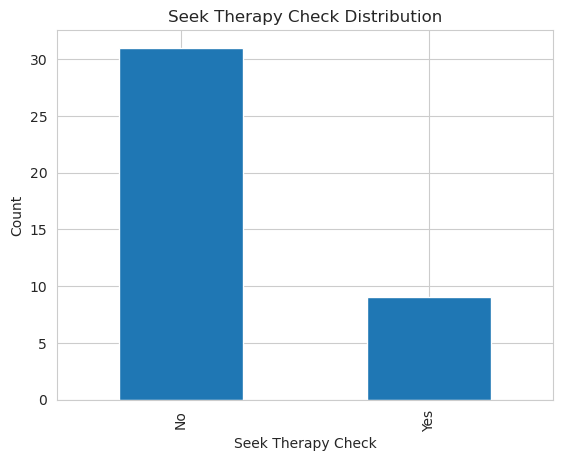

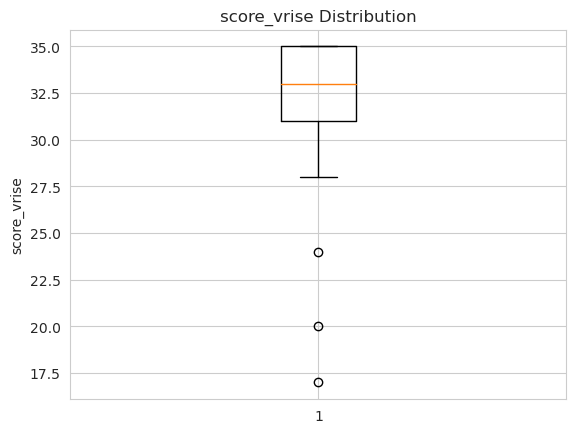

count    40.00000
mean     31.87500
std       3.98193
min      17.00000
25%      31.00000
50%      33.00000
75%      35.00000
max      35.00000
Name: score_vrise, dtype: float64


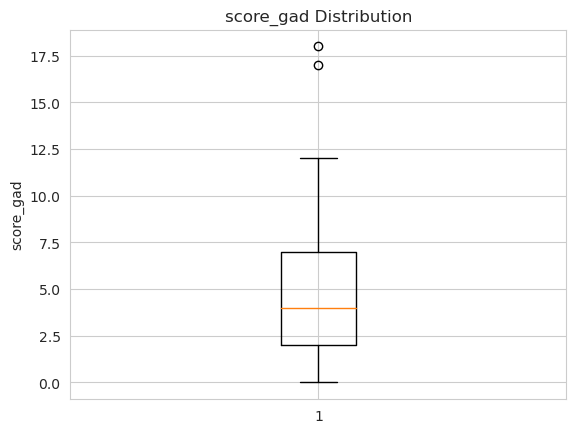

count    40.000000
mean      5.000000
std       4.314555
min       0.000000
25%       2.000000
50%       4.000000
75%       7.000000
max      18.000000
Name: score_gad, dtype: float64


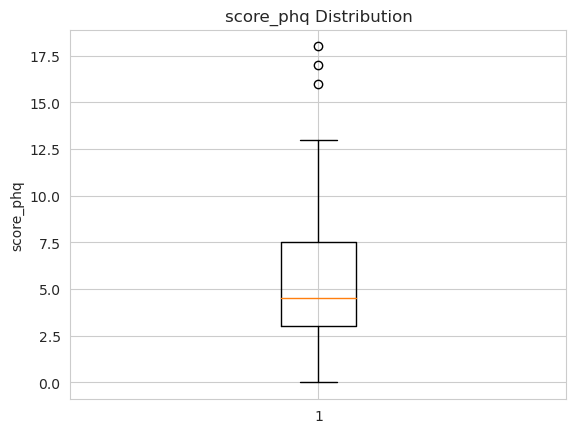

count    40.000000
mean      6.025000
std       4.627053
min       0.000000
25%       3.000000
50%       4.500000
75%       7.500000
max      18.000000
Name: score_phq, dtype: float64


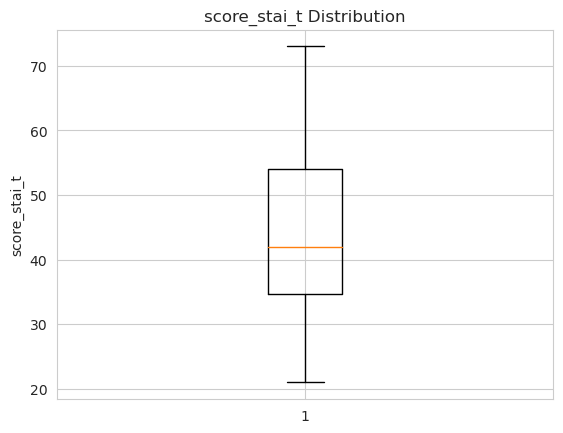

count    40.000000
mean     45.000000
std      14.628739
min      21.000000
25%      34.750000
50%      42.000000
75%      54.000000
max      73.000000
Name: score_stai_t, dtype: float64


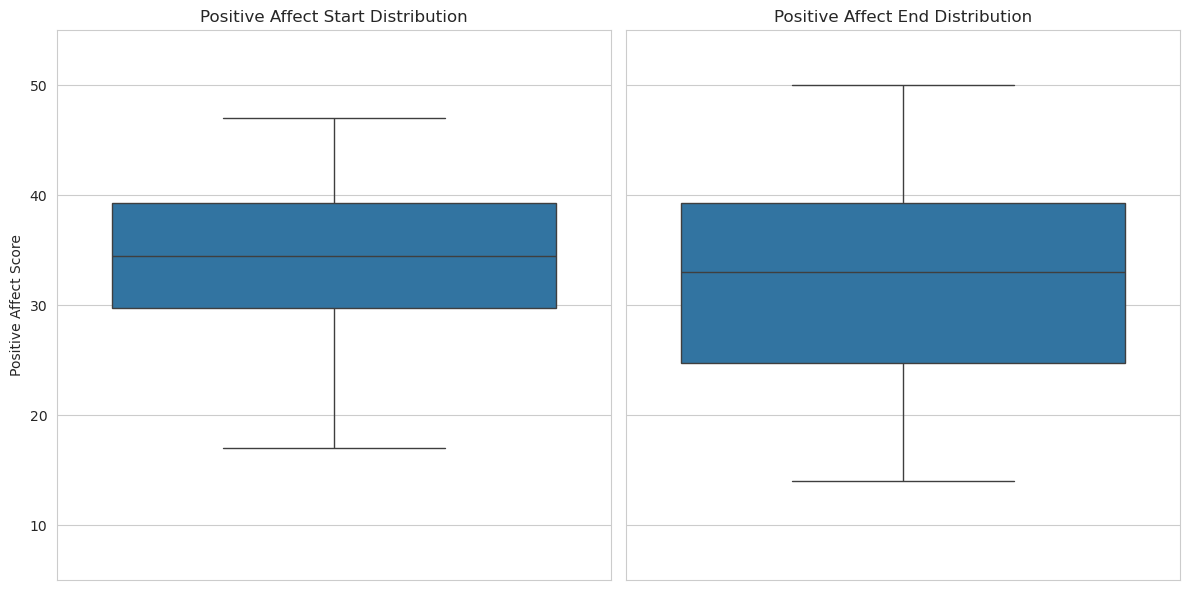

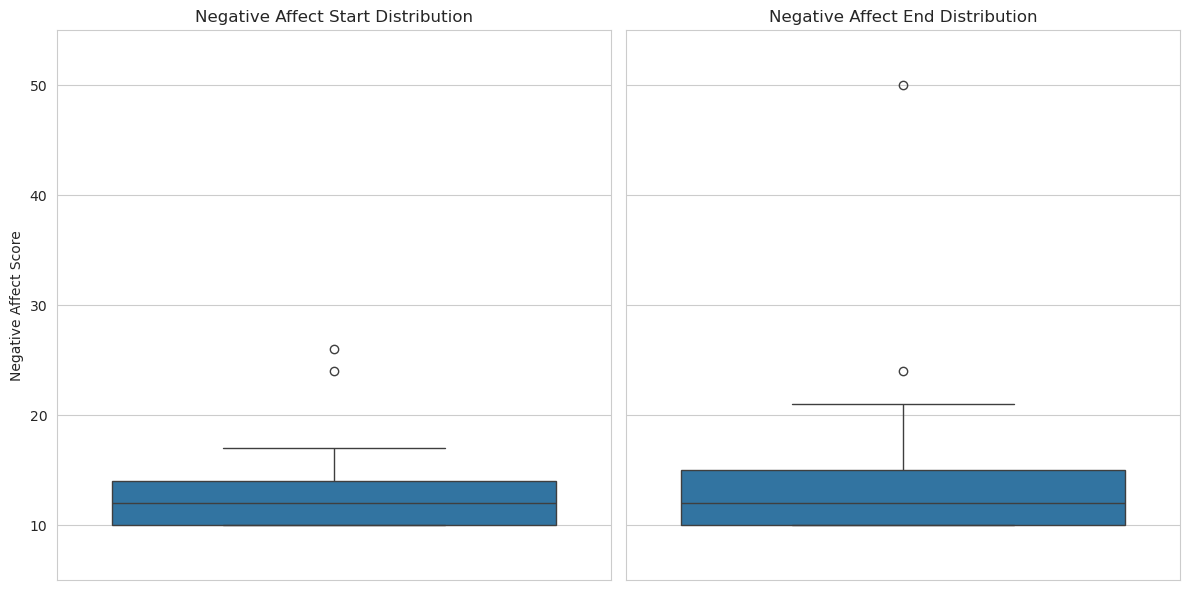

In [ ]:
# Plot barplot for seek_therapy_check(1 for yes, 2 for no)
therapy_counts = main_data['seek_therapy_check'].value_counts()
therapy_counts.index = ['No', 'Yes']
therapy_counts.plot(kind='bar')
plt.title('Seek Therapy Check Distribution')
plt.xlabel('Seek Therapy Check')
plt.ylabel('Count')
plt.show()

# Plot boxplots for score_vrise, score_gad, score_phq, score_stai_t
score_columns = ['score_vrise', 'score_gad', 'score_phq', 'score_stai_t']
for col in score_columns:
    plt.figure()
    plt.title(f'{col} Distribution')
    plt.boxplot(main_data[col])
    plt.ylabel(col)
    plt.show()
    print(main_data[col].describe())

# For positive affect and negative affect, two boxplots side by side with same y-axis
pos_min = min(min(main_data['positive_affect_start'].min(), main_data['positive_affect_end'].min()),5)
pos_max = max(max(main_data['positive_affect_start'].max(), main_data['positive_affect_end'].max()),55)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxplot(y=main_data['positive_affect_start'], ax=axes[0])
axes[0].set_title('Positive Affect Start Distribution')
axes[0].set_ylabel('Positive Affect Score')
axes[0].set_ylim(pos_min, pos_max)

sns.boxplot(y=main_data['positive_affect_end'], ax=axes[1])
axes[1].set_title('Positive Affect End Distribution')
axes[1].set_ylabel('Positive Affect Score')
axes[1].set_ylim(pos_min, pos_max)

plt.tight_layout()
plt.show()

neg_min = min(min(main_data['negative_affect_start'].min(), main_data['negative_affect_end'].min()),5)
neg_max = max(max(main_data['negative_affect_start'].max(), main_data['negative_affect_end'].max()),55)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxplot(y=main_data['negative_affect_start'], ax=axes[0])
axes[0].set_title('Negative Affect Start Distribution')
axes[0].set_ylabel('Negative Affect Score')
axes[0].set_ylim(neg_min, neg_max)

sns.boxplot(y=main_data['negative_affect_end'], ax=axes[1])
axes[1].set_title('Negative Affect End Distribution')
axes[1].set_ylabel('Negative Affect Score')
axes[1].set_ylim(neg_min, neg_max)


plt.tight_layout()
plt.show()


/tmp/ipykernel_1847/2963030458.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phq_counts.index, y=phq_counts.values, palette='Set3')


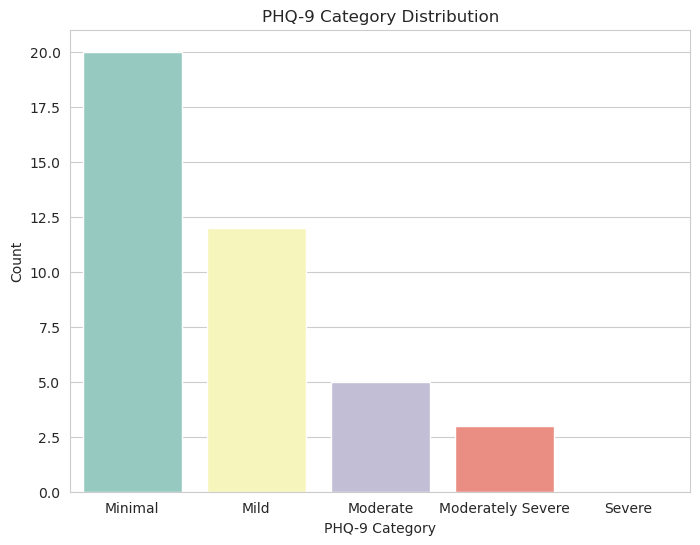

/tmp/ipykernel_1847/2963030458.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gad_counts.index, y=gad_counts.values, palette='Set2')


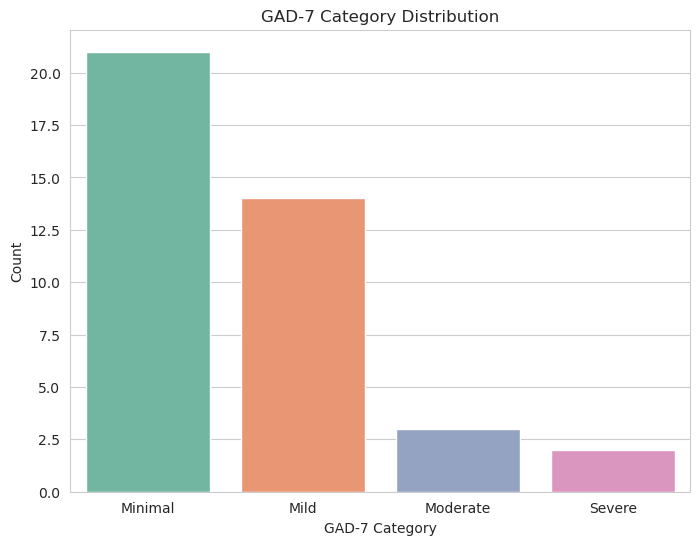

/tmp/ipykernel_1847/2963030458.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stai_counts.index, y=stai_counts.values, palette='Set1')


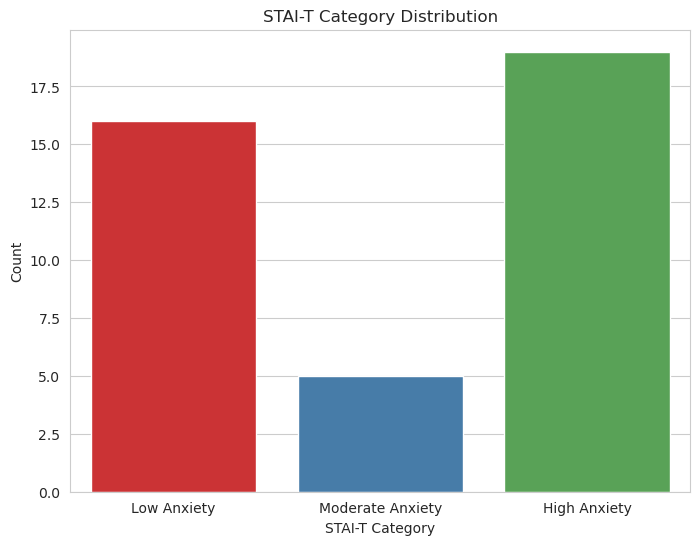

In [63]:
"""PHQ 9: minimal (0-4), mild (5-9), moderate (10-14), moderately severe (15-19), and severe (20-27)
GAD-7: minimal (0-4), mild (5-9), moderate (10-14), and severe (15-21)
STAI-T: low-anxiety (20-37), moderate-anxiety (38-44), and high-anxiety (45-80)
"""
# Categorize PHQ-9 scores
def categorize_phq(score):
    if score <= 4:
        return 'Minimal'
    elif score <= 9:
        return 'Mild'
    elif score <= 14:
        return 'Moderate'
    elif score <= 19:
        return 'Moderately Severe'
    else:
        return 'Severe'
    
main_data['phq_category'] = main_data['score_phq'].apply(categorize_phq)
# Categorize GAD-7 scores
def categorize_gad(score):
    if score <= 4:
        return 'Minimal'
    elif score <= 9:
        return 'Mild'
    elif score <= 14:
        return 'Moderate'
    else:
        return 'Severe'
    
def categorize_stai(score):
    if score <= 37:
        return 'Low Anxiety'
    elif score <= 44:
        return 'Moderate Anxiety'
    else:
        return 'High Anxiety'
    
main_data['gad_category'] = main_data['score_gad'].apply(categorize_gad)
main_data['stai_category'] = main_data['score_stai_t'].apply(categorize_stai)
# Plot bar plots for PHQ-9 categories
plt.figure(figsize=(8, 6))
phq_counts = main_data['phq_category'].value_counts()
# Reorder the index to ensure correct category order
phq_counts = phq_counts.reindex(['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe'])
sns.barplot(x=phq_counts.index, y=phq_counts.values, palette='Set3')
plt.title('PHQ-9 Category Distribution')
plt.xlabel('PHQ-9 Category')
plt.ylabel('Count')
plt.show()

# Plot bar plots for GAD-7 categories
plt.figure(figsize=(8, 6))
gad_counts = main_data['gad_category'].value_counts()
# Reorder the index to ensure correct category order
gad_counts = gad_counts.reindex(['Minimal', 'Mild', 'Moderate', 'Severe'])
sns.barplot(x=gad_counts.index, y=gad_counts.values, palette='Set2')
plt.title('GAD-7 Category Distribution')
plt.xlabel('GAD-7 Category')
plt.ylabel('Count')
plt.show()

# Plot bar plots for STAI-T categories
plt.figure(figsize=(8, 6))
stai_counts = main_data['stai_category'].value_counts()
# Reorder the index to ensure correct category order
stai_counts = stai_counts.reindex(['Low Anxiety', 'Moderate Anxiety', 'High Anxiety'])
sns.barplot(x=stai_counts.index, y=stai_counts.values, palette='Set1')
plt.title('STAI-T Category Distribution')
plt.xlabel('STAI-T Category')
plt.ylabel('Count')
plt.show()

       valence_v1  valence_v2  valence_v3  valence_v4  valence_v5
count   40.000000   40.000000   40.000000   40.000000   40.000000
mean     5.200000    6.525000    6.150000    3.675000    7.125000
std      1.667179    1.753933    1.610064    1.845125    1.682298
min      1.000000    3.000000    3.000000    1.000000    1.000000
25%      4.000000    5.000000    5.000000    2.000000    7.000000
50%      5.000000    6.000000    6.000000    3.000000    7.000000
75%      6.000000    8.000000    7.000000    5.000000    8.000000
max      9.000000    9.000000    9.000000    8.000000    9.000000


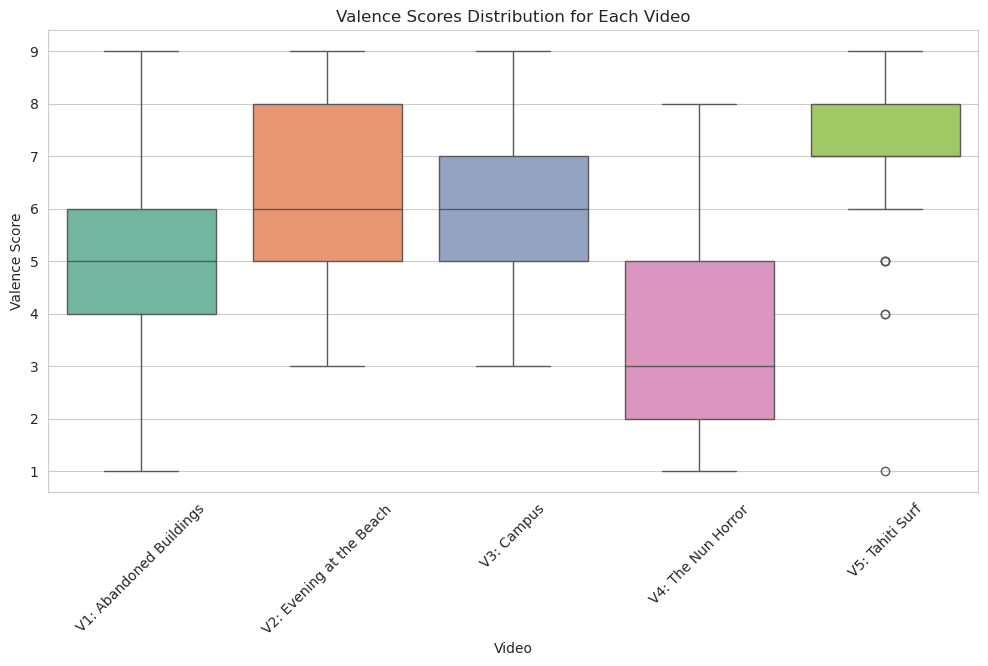

       arousal_v1  arousal_v2  arousal_v3  arousal_v4  arousal_v5
count   40.000000   40.000000   40.000000   40.000000   40.000000
mean     4.600000    4.650000    4.325000    5.950000    6.500000
std      2.216488    2.032429    2.164841    1.678675    1.694637
min      1.000000    1.000000    1.000000    2.000000    2.000000
25%      3.000000    3.000000    2.750000    5.000000    6.000000
50%      5.000000    5.000000    4.500000    6.000000    7.000000
75%      6.000000    6.000000    5.250000    7.000000    8.000000
max      9.000000    8.000000    9.000000    9.000000    9.000000


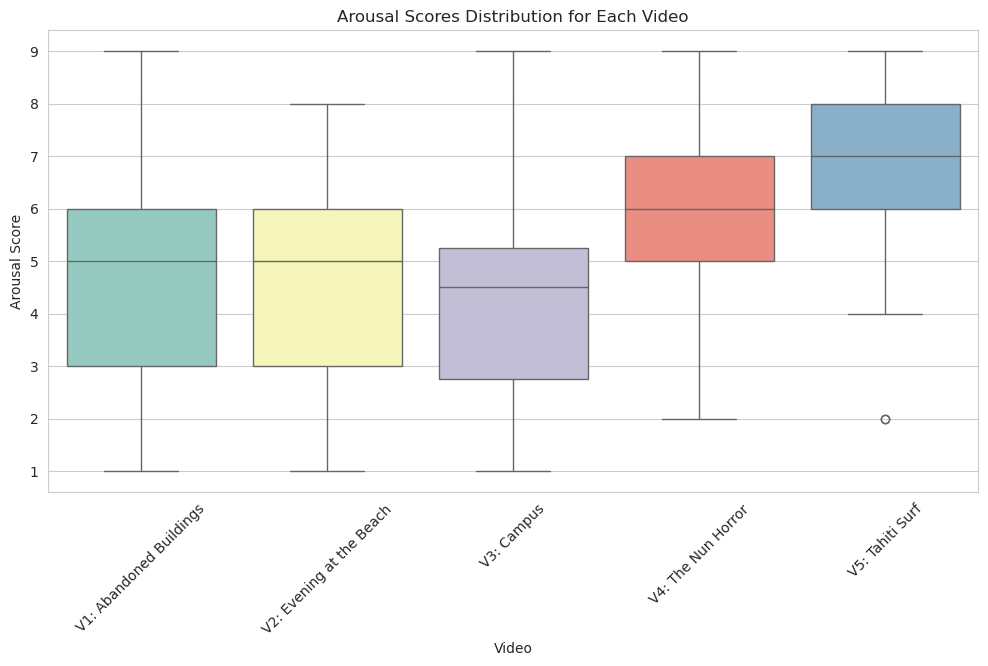

In [64]:
# Valence and arousal scores for each video
valence_columns=['valence_v1','valence_v2','valence_v3','valence_v4','valence_v5']
arousal_columns=['arousal_v1','arousal_v2','arousal_v3','arousal_v4','arousal_v5']
"""V1: Abandoned Buildings, V2: Evening at the Beach, V3: Campus, V4: 
The Nun Horror, V5: Tahiti Surf"""
video_labels=['V1: Abandoned Buildings', 'V2: Evening at the Beach', 'V3: Campus', 'V4: The Nun Horror', 'V5: Tahiti Surf']

# Plot boxplots for valence scores side by side
plt.figure(figsize=(12, 6))
sns.boxplot(data=main_data[valence_columns], palette='Set2')
print(main_data[valence_columns].describe())
plt.title('Valence Scores Distribution for Each Video')
plt.xlabel('Video')
plt.xticks(ticks=range(len(video_labels)), labels=video_labels, rotation=45)
plt.ylabel('Valence Score')
plt.show()

# Plot boxplots for arousal scores side by side
plt.figure(figsize=(12, 6))
sns.boxplot(data=main_data[arousal_columns], palette='Set3')
print(main_data[arousal_columns].describe())
plt.title('Arousal Scores Distribution for Each Video')
plt.xlabel('Video')
plt.xticks(ticks=range(len(video_labels)), labels=video_labels, rotation=45)
plt.ylabel('Arousal Score')
plt.show()